In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Rudra\Desktop\credit-risk-ml\data\Raw\loan.csv", low_memory=False)
df.shape


(39717, 111)

In [13]:
categorical_features = df.select_dtypes(include='object').columns.tolist()
numerical_features = df.select_dtypes(exclude='object').columns.tolist()

len(categorical_features), len(numerical_features)

df = df[df['loan_status'].isin(['Fully Paid','Charged Off'])]

#creating a binary target
df.loc[:, 'target'] = df['loan_status'].map({
    'Fully Paid': 0,
    'Charged Off': 1
})


df['target'].value_counts()

target
0    32950
1     5627
Name: count, dtype: int64

In [5]:
df[numerical_features].describe()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,installment,annual_inc,dti,delinq_2yrs,inq_last_6mths,...,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
count,3.971700e+04,3.971700e+04,39717.000000,39717.000000,39717.000000,39717.000000,3.971700e+04,39717.000000,39717.000000,39717.000000,...,0.0,0.0,0.0,0.0,39020.000000,39678.0,0.0,0.0,0.0,0.0
mean,6.831319e+05,8.504636e+05,11219.443815,10947.713196,10397.448868,324.561922,6.896893e+04,13.315130,0.146512,0.869200,...,NaN,NaN,NaN,NaN,0.043260,0.0,NaN,NaN,NaN,NaN
std,2.106941e+05,2.656783e+05,7456.670694,7187.238670,7128.450439,208.874874,6.379377e+04,6.678594,0.491812,1.070219,...,NaN,NaN,NaN,NaN,0.204324,0.0,NaN,NaN,NaN,NaN
min,5.473400e+04,7.069900e+04,500.000000,500.000000,0.000000,15.690000,4.000000e+03,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,0.000000,0.0,NaN,NaN,NaN,NaN
25%,5.162210e+05,6.667800e+05,5500.000000,5400.000000,5000.000000,167.020000,4.040400e+04,8.170000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,0.000000,0.0,NaN,NaN,NaN,NaN
50%,6.656650e+05,8.508120e+05,10000.000000,9600.000000,8975.000000,280.220000,5.900000e+04,13.400000,0.000000,1.000000,...,NaN,NaN,NaN,NaN,0.000000,0.0,NaN,NaN,NaN,NaN
75%,8.377550e+05,1.047339e+06,15000.000000,15000.000000,14400.000000,430.780000,8.230000e+04,18.600000,0.000000,1.000000,...,NaN,NaN,NaN,NaN,0.000000,0.0,NaN,NaN,NaN,NaN
max,1.077501e+06,1.314167e+06,35000.000000,35000.000000,35000.000000,1305.190000,6.000000e+06,29.990000,11.000000,8.000000,...,NaN,NaN,NaN,NaN,2.000000,0.0,NaN,NaN,NaN,NaN


In [6]:
df[numerical_features].skew

<bound method DataFrame.skew of             id  member_id  loan_amnt  funded_amnt  funded_amnt_inv  \
0      1077501    1296599       5000         5000           4975.0   
1      1077430    1314167       2500         2500           2500.0   
2      1077175    1313524       2400         2400           2400.0   
3      1076863    1277178      10000        10000          10000.0   
4      1075358    1311748       3000         3000           3000.0   
...        ...        ...        ...          ...              ...   
39712    92187      92174       2500         2500           1075.0   
39713    90665      90607       8500         8500            875.0   
39714    90395      90390       5000         5000           1325.0   
39715    90376      89243       5000         5000            650.0   
39716    87023      86999       7500         7500            800.0   

       installment  annual_inc    dti  delinq_2yrs  inq_last_6mths  ...  \
0           162.87     24000.0  27.65            0  

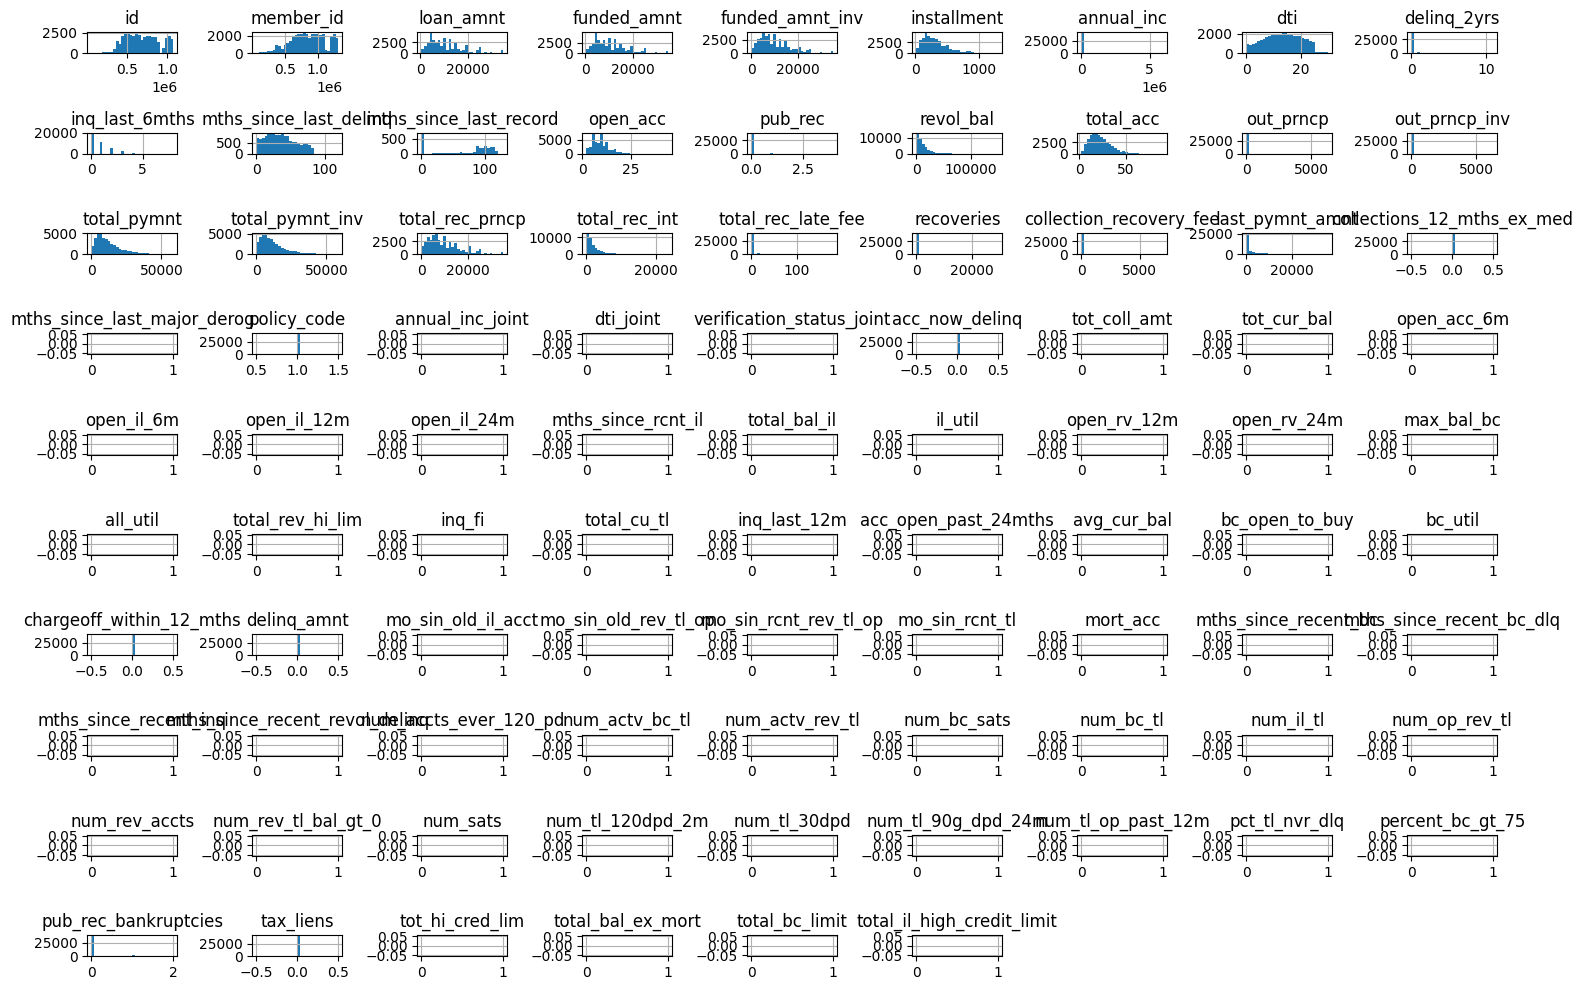

In [9]:
import matplotlib.pyplot as plt

df[numerical_features].hist(bins=30, figsize=(15,10))
plt.tight_layout()
plt.show()


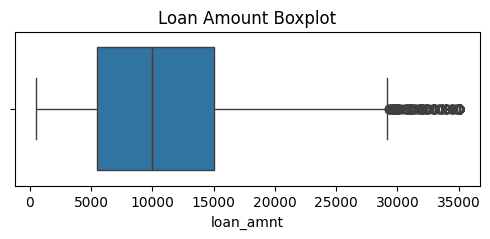

In [10]:
import seaborn as sns

plt.figure(figsize=(6,2))
sns.boxplot(x=df['loan_amnt'])
plt.title('Loan Amount Boxplot')
plt.show()


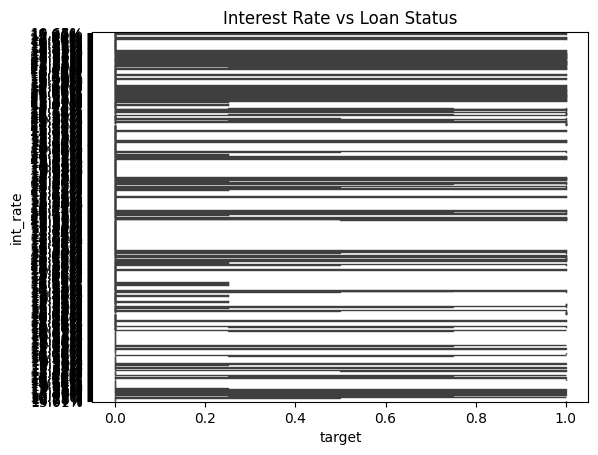

In [15]:
sns.boxplot(
    x='target',
    y='int_rate',
    data=df,
    showfliers=False
)
plt.title('Interest Rate vs Loan Status')
plt.show()



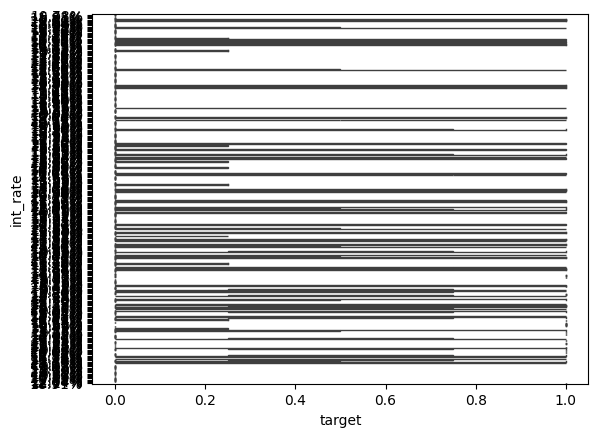

In [16]:
sample_df = df.sample(5000, random_state=42)

sns.boxplot(
    x='target',
    y='int_rate',
    data=sample_df,
    showfliers=False
)
plt.show()


In [17]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols

Index(['term', 'int_rate', 'grade', 'sub_grade', 'emp_title', 'emp_length',
       'home_ownership', 'verification_status', 'issue_d', 'loan_status',
       'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code',
       'addr_state', 'earliest_cr_line', 'revol_util', 'initial_list_status',
       'last_pymnt_d', 'next_pymnt_d', 'last_credit_pull_d',
       'application_type'],
      dtype='object')

In [18]:
df['grade'].value_counts()


grade
B    11675
A    10045
C     7834
D     5085
E     2663
F      976
G      299
Name: count, dtype: int64

In [19]:
df.groupby('grade')['target'].mean().sort_values(ascending=False)


grade
G    0.337793
F    0.326844
E    0.268494
D    0.219862
C    0.171943
B    0.122056
A    0.059930
Name: target, dtype: float64

In [20]:
df['term'].value_counts()

term
36 months    29096
60 months     9481
Name: count, dtype: int64

In [21]:
df.groupby('term')['target'].mean().sort_values(ascending=False)


term
60 months    0.253138
36 months    0.110909
Name: target, dtype: float64

In [22]:
df['home_ownership'].value_counts()

home_ownership
RENT        18480
MORTGAGE    17021
OWN          2975
OTHER          98
NONE            3
Name: count, dtype: int64

In [23]:
df.groupby('home_ownership')['target'].mean().sort_values(ascending=False)

home_ownership
OTHER       0.183673
RENT        0.153626
OWN         0.148908
MORTGAGE    0.136713
NONE        0.000000
Name: target, dtype: float64

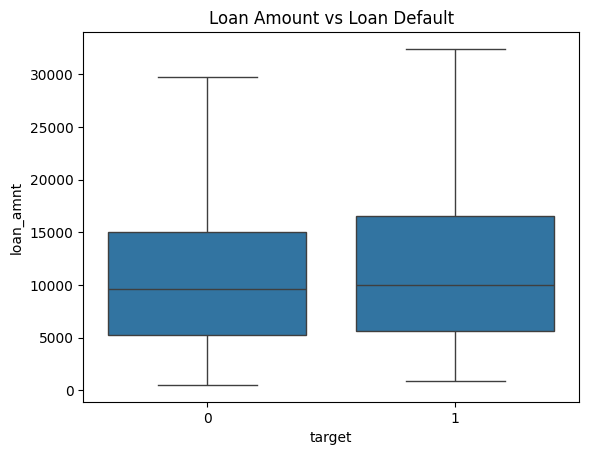

In [24]:
sns.boxplot(
    x='target',
    y='loan_amnt',
    data=df,
    showfliers=False
)
plt.title('Loan Amount vs Loan Default')
plt.show()


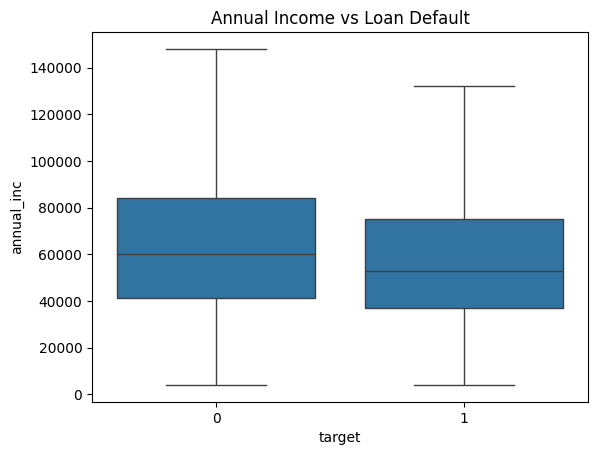

In [25]:
sns.boxplot(
    x='target',
    y='annual_inc',
    data=df,
    showfliers=False
)
plt.title('Annual Income vs Loan Default')
plt.show()


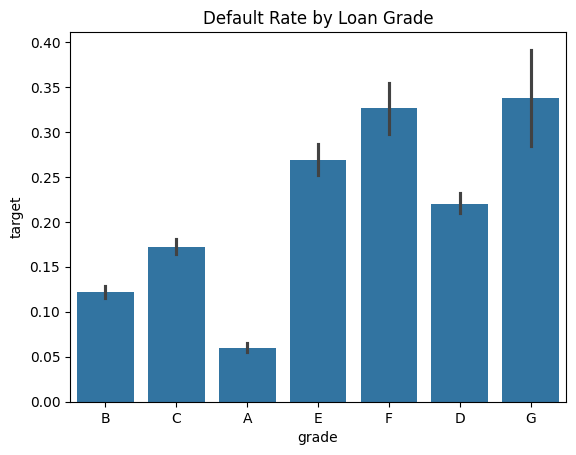

In [26]:
sns.barplot(x='grade', y='target', data=df, estimator='mean')
plt.title('Default Rate by Loan Grade')
plt.show()


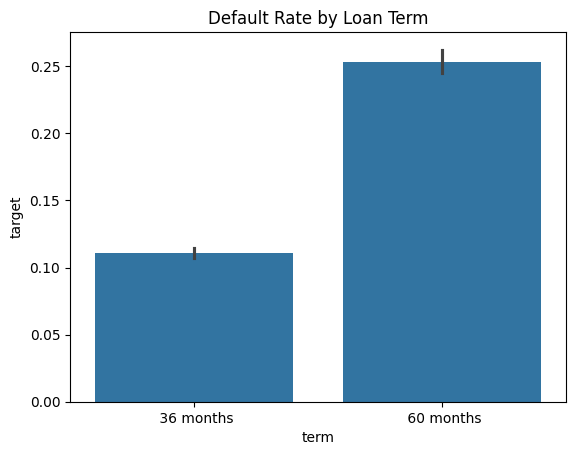

In [27]:
sns.barplot(x='term', y='target', data=df, estimator='mean')
plt.title('Default Rate by Loan Term')
plt.show()


In [29]:
corr = df[numerical_features].corr()
corr


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,installment,annual_inc,dti,delinq_2yrs,inq_last_6mths,...,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,target
id,1.000000,0.993534,0.120614,0.131283,0.231603,0.076088,0.005572,0.091785,-0.008417,-0.041021,...,NaN,NaN,NaN,-0.007997,NaN,NaN,NaN,NaN,NaN,0.042390
member_id,0.993534,1.000000,0.120393,0.130307,0.241324,0.070918,0.006442,0.092910,-0.007905,-0.045879,...,NaN,NaN,NaN,-0.007346,NaN,NaN,NaN,NaN,NaN,0.039798
loan_amnt,0.120614,0.120393,1.000000,0.981790,0.937922,0.932260,0.268999,0.062436,-0.031951,0.012940,...,NaN,NaN,NaN,-0.035981,NaN,NaN,NaN,NaN,NaN,0.059463
funded_amnt,0.131283,0.130307,0.981790,1.000000,0.956172,0.958035,0.264798,0.062194,-0.031866,0.012857,...,NaN,NaN,NaN,-0.036995,NaN,NaN,NaN,NaN,NaN,0.056497
funded_amnt_inv,0.231603,0.241324,0.937922,0.956172,1.000000,0.905464,0.251981,0.070663,-0.038171,-0.002800,...,NaN,NaN,NaN,-0.041193,NaN,NaN,NaN,NaN,NaN,0.037781
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
tot_hi_cred_lim,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_bal_ex_mort,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_bc_limit,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_il_high_credit_limit,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
